In [ ]:
import quanguru as qg
import numpy as np
from scipy.integrate import quad
import scipy.linalg as linA
import scipy.sparse as sp
import platform
from matplotlib.colors import LogNorm
from matplotlib import pyplot as plt

# 19 - Jaynes-Cummings Unitary Fidelity with Smooth Control Pulse

The Jaynes-Cummings Hamiltonian is written as

$H_{JC} = \hbar\omega_{c} a^{\dagger}a + \frac{1}{2}\hbar\omega_{q}\sigma_{z} + \hbar g(a^{\dagger}\sigma_{-} + a\sigma_{+})$

where $\sigma_{\pm} = (\sigma_{x} \pm i\sigma_{y})/2$ are raising/lowering operators for a two-level system, $\sigma_{\mu}$ are the Pauli spin operators with $\mu\in\{x,y,z\}$, $a^{\dagger}$ and $a$ are the creation and annihilation operators for the field mode, and $\omega_{c}$, $\omega_{q}$, and $g$ are the cavity-field, qubit, and coupling (angular-) frequencies, respectively.

Here, we will evaluate the unitary evolution of a JC system under a smooth sinusoidal pulse and compare the fidelity of using this pulse with an ideal square pulse.

We will use the below parameters in our simulation

In [2]:

# parameters for the Hamiltonian
coef = 2*np.pi          # coefficient to convert frequency into angular frequency
delta = 1.0*coef        # cavity-qubit detuning
g = 20*delta/1000       # coupling strength
wq = 0                  # qubit frequency
wc = wq + delta         # cavity frequency
cavDim = 100            # cavity dimension

# parameters for the evolution
stepCount = 100        # step count


and we can describe the JC-Hamiltonian/system in QuanGuru as

In [3]:

# Qubit for the JC model
QubitJC = qg.Qubit(frequency=wq, alias='qubit')

# Cavity for the JC model
CavityJC = qg.Cavity(frequency=wc, dimension=cavDim, alias='cavity')

# JC model consists of a qubit and cavity
JCSystem = QubitJC + CavityJC
JCSystem.alias = "JCSystem"


We define a custom createUnitary function (`cUJC`) that returns the analytic Jaynes–Cummings step unitary (`qg.UJC`) to avoid repeated exponentiations and reduced computational overhead, expecially for large cavity dimensions.


In [4]:

# This captures all the physics of the JC Model and does not require the coupling terms to be defined

def cUJC(self, collapseOps = None, decayRates = None):
    kwargs = {
        "wq": self.getByNameOrAlias('qubit').frequency,
        "wc": self.getByNameOrAlias('cavity').frequency,
        "g": g,
        "t": self.simulation.stepSize,
        "dimC": self.getByNameOrAlias('cavity').dimension
    }
    return qg.UJC(sparse=True, **kwargs)



The core of this approach is using the Identity matrix as the initial state. This makes the evolved “state” equal to the accumulated total unitary after the simulation.

In [5]:
# Simulation Parameters
JCSystem.protocols[0].createUnitary = cUJC
JCSystem.initialState = qg.identity(JCSystem.dimension)

We define the shape and paramters of our smooth sinusoidal pulse (`dOmegaSine`) with:
- Quadratic-sine ramp up (0 → A) over tr
- Flat top of duration tf at amplitude A
- Symmetric ramp down (A → 0) over tr

In [6]:
# Smooth sinusoidal pulse
def dOmegaSine(t,A,tr,tf):
    """
    Parameters
        t - float, array of floats
            the time input of the function
        A - float
            the max amplitude of the pulse
        tr - float
            the rising and falling time of the trapezoidal pulse
        tf - float
            the duration for which the pulse sits at max amplitude (flat duration)
    """
    if t<tr:
        return A * np.sin(np.pi*t/(2*tr))*np.sin(np.pi*t/(2*tr))
    elif t<tr+tf:
        return A
    else:
        return A * np.sin(np.pi*(t-tf)/(2*tr))*np.sin(np.pi*(t-tf)/(2*tr))


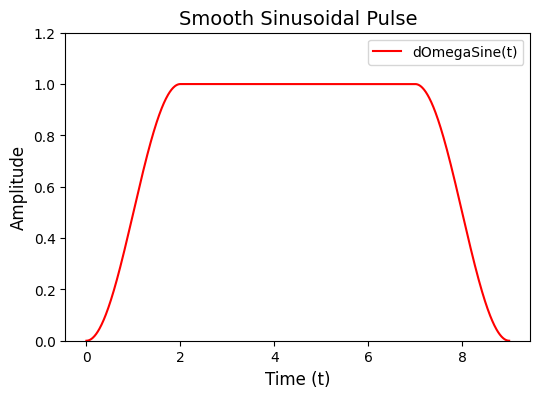

In [7]:
# Plotting the dOmegaSine function

# Example parameters for the pulse
A, tr, tf = 1.0, 2.0, 5.0

timeList = np.linspace(0, tr + tf + tr, 1000)  
pulseValues = [dOmegaSine(t, A, tr, tf) for t in timeList]  

# Plot the function
plt.figure(figsize=(6, 4))
plt.plot(timeList, pulseValues, label='dOmegaSine(t)', color='red')
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.ylim(0, 1.2)
plt.title('Smooth Sinusoidal Pulse', fontsize=14)
plt.legend()
plt.show()

Here we set our parameter's time-dependency callback function. In this case, the frequency of our qubit follows the dOmegaSine function with a constant term (initial qubit frequency).

`qubit.frequency = wq + dOmegaSine(t, amp, tr, tf)`

We initiliase auxiliary parameters (`amp`, `tr`, `tf`) in `auxDict` so that we can perform sweeps with these parameters. 


In [8]:
# Initial Pulse Parameters
# Since 'tr' and 'tf' are being swept, the value they are set at here does not matter
# Using auxDict to store and manage parameters not inherent to QuantumSystems

QubitJC.auxDict['amp'] = delta    # Pulse amplitude
QubitJC.auxDict['tr'] = 0.0     # Rising time
QubitJC.auxDict['tf'] = 0.0      # Flat time

# Defining a suitable timeDependency function using the sinusoidal function
def qubFrequencyTimeDependency(qsys, ti):
    qsys.frequency = wq + dOmegaSine(
        ti,
        qsys.auxDict['amp'],
        qsys.auxDict['tr'],
        qsys.auxDict['tf'])
    
JCSystem.getByNameOrAlias('qubit').timeDependency = qubFrequencyTimeDependency

We can now create sweeps with parameters not inherent to `QuantumSystem` or `QTerm` objects by first initiliasing them as auxillary parameters in `auxDict`.

When creating multiple sweeps we can set sweep parameter `combinatorial = True` so that every combination of the sweep parameters are swept.
With this, we can obtain a full parameter-space landscape.


Here, we sweep the rise time (`tr`) and flat time (`tf`) of our smooth sinusoidal pulse to map the fidelity landscape of our pulse parameters.

In [9]:

### Sweeps
# Sweeping rising time and flat time
trSweep = JCSystem.Sweep.createSweep(
    system=QubitJC,
    sweepKey='tr', 
    sweepList=np.linspace(0.1, 5 ,100)
    )

tfSweep = JCSystem.Sweep.createSweep(
    system=QubitJC, 
    sweepKey='tf', 
    sweepList=np.linspace(0, 20, 50), 
    combinatorial = True
    )


We set our simulation time to be the same as the duration of the smooth pulse rise time. This is because the total unitary can be determined from the unitary  of the rise time of the pulse. It also reduces the total simulation length.

In [10]:

### PreCompute Function
def preCompute(qSim):
    # Using the the preCompute function to set the simulation length based on pulse parameters
    QubitJC = qSim.getByNameOrAlias("qubit")
    qSim.totalTime = QubitJC.auxDict['tr']
    qSim.stepCount = stepCount

JCSystem.preCompute = preCompute


## Post-Processing: Phase Accumulation and Effective Interaction Time

To compare the smooth pulse with an ideal square pulse, we need to account for the accumulated phase and determine the effective interaction time. We define a number of functions to accomplish this.

### Unitary Fidelity

The fidelity between two unitary operators $U_1$ and $U_2$ is defined as:

$$F(U_1, U_2) = \left|\frac{\text{Tr}(U_1^\dagger U_2)}{d}\right|^2$$

where $d$ is the dimension of the Hilbert space. This metric quantifies how closely the two unitaries agree, with $F = 1$ indicating perfect agreement.

### Phase Accumulation Integral

The smooth pulse modulates the qubit frequency as:
$$\omega_q(t) = \omega_q^{(0)} + \text{dOmegaSine}(t, A, t_r, t_f)$$

To track the accumulated phase in the rotating frame, we need the time integral:

$$\Phi(t) = \int_0^t \text{dOmegaSine}(t', A, t_r, t_f) \, dt'$$

The function `dOmegaSineInt(t, Ao, tro, tfo)` computes this analytically in three segments:

1. **Rise region** ($0 \leq t < t_r$):
   $$\Phi(t) = \frac{A t}{2} - \frac{A t_r}{2\pi} \sin\left(\frac{\pi t}{t_r}\right)$$

2. **Flat region** ($t_r \leq t < t_r + t_f$):
   $$\Phi(t) = A(t - t_r) + \frac{A t_r}{2}$$

3. **Fall region** ($t \geq t_r + t_f$):
   $$\Phi(t) = A t_f + \frac{A(t - t_f)}{2} - \frac{A t_r}{2\pi} \sin\left(\frac{\pi(t - t_f)}{t_r}\right)$$

### Effective Interaction Time via Dyson Series

For an ideal square pulse with constant amplitude at resonance, the interaction picture Hamiltonian is time-independent. For our smooth pulse, we work in a frame rotating at the cavity frequency and must determine the *effective* interaction time $t_{\text{sim}}$ that produces the same unitary evolution.

Using first-order perturbation theory (Dyson series), we compute integrals of the form:

$$\int_0^T \cos[\delta t - \Phi(t)] \, dt \quad \text{and} \quad \int_0^T \sin[\delta t - \Phi(t)] \, dt$$

where $\delta = \omega_c - \omega_q^{(0)}$ is the detuning.

The helper functions:
- `cosinner(x, Ao, tro, tfo)`: Returns $\cos[\delta x - \Phi(x)]$
- `sinner(x, Ao, tro, tfo)`: Returns $\sin[\delta x - \Phi(x)]$
- `integrator(Ao, tro, tfo, x)`: Uses `scipy.integrate.quad` to numerically integrate both functions from 0 to $x$

The first component of `integrator` output gives $t_{\text{sim}}$, the effective interaction time for the equivalent square pulse comparison.

The vectorization of `dOmegaSineInt` allows it to accept arrays, improving efficiency when computing over many time points.

In [11]:

### Post Processing
# Unitary fidelity function
def jfidelity(op1, op2):
    dim = op1.shape[0]
    tr = qg.trace(qg.hc(op1)@op2)
    return (abs(tr)/dim)**2

# Defines the definite integral of the pulse above between 0 and t
def dOmegaSineInt(t,Ao,tro,tfo):
    """
    Parameters
        t - float, array of floats
            the time input of the function
        Ao - float
            parameter of the trapezoidal/sinusoidal pulse that defines the max amplitude
        tro - float
            parameter of the trapezoidal/sinusoidal pulse that defines the rising and falling time pulse
        tfo - float
            parameter of the trapezoidal/sinusoidal pulse that defines the duration for which the pulse sits at max amplitude
    """
    if t<tro:
        return Ao*t/2 - Ao*tro*np.sin(np.pi*t/tro)/(2*np.pi)
    elif t<tro+tfo:
        return Ao*(t-tro) + Ao*tro/2
    else:
        return Ao*tfo + Ao*(t-tfo)/2 - Ao*tro*np.sin(np.pi*(t-tfo)/tro)/(2*np.pi)

dOmegaSineInt = np.vectorize(dOmegaSineInt)

# Determining the first order coefficients for the Smooth Pulse Dyson Series
def sinner(x,Ao,tro,tfo):
    return np.sin(delta*x - dOmegaSineInt(x,Ao,tro,tfo))
def cosinner(x,Ao,tro,tfo):
    return np.cos(delta*x - dOmegaSineInt(x,Ao,tro,tfo))
def integrator(Ao,tro,tfo,x): 
    return quad(cosinner,0,x,args=(Ao,tro,tfo), limit=200)[0], quad(sinner,0,x,args=(Ao,tro,tfo), limit=200)[0]


In our postCompute function we determine the final unitary for our smooth sinusoidal pulse and an ideal square pulse and calculate the fidelity between these unitaries. 

Steps:
1. Retrieve rise-time unitary 
2. Build flat unitary segment at constant amplitude
3. Use transpose of rise-time unitary for symmetric fall
4. Apply phase corrections (rotating frame adjustments)
5. Compute ideal square pulse unitary (same effective interaction time)
6. Calcualte fidelity

In [12]:
### PostCompute Function
def postCompute(qSim):
    uSmooth = qSim.protocols[0].currentState
    cavdim = qSim.getByNameOrAlias('cavity').dimension
    time = 2*qSim.auxDict['tr'] + qSim.auxDict['tf']

    # Forms the final unitary by left matrix multiplying the unitary obtained at the end of the rise time with the
    # unitary for the flat duration followed by the fall time ( = transpose of rise time unitary)
    uSmooth = np.transpose(uSmooth)@qg.UJC(wq+qSim.auxDict['amp'],wc,g,qSim.auxDict['tf'],cavdim,sparse=True)@uSmooth

    tsim = integrator(qSim.auxDict['amp'],qSim.auxDict['tr'],qSim.auxDict['tf'], time)[0]   

    # Compute the unitary of an ideal sqaure pulse
    uJC = qg.UJC(wc,wc,g,tsim,cavdim,sparse=True)

    # Apply phase correction
    integral = dOmegaSineInt(time,qSim.auxDict['amp'],qSim.auxDict['tr'],qSim.auxDict['tf'])
    
    uz = linA.expm(-0.5j*integral*sp.kron(qg.identity(cavdim), qg.sigmaz(), 'csc').toarray() + 1j*wc*time*sp.kron(qg.number(cavdim), qg.identity(2), 'csc').toarray())
    uz2 = linA.expm(0.5j*wc*tsim*sp.kron(qg.identity(cavdim), qg.sigmaz(), 'csc').toarray() - 1j*wc*tsim*sp.kron(qg.number(cavdim), qg.identity(2), 'csc').toarray())
    uSmooth = uz2@uz@uSmooth

    qSim.qRes.resultsDict['JCfidelity'] = jfidelity(uJC,uSmooth)

JCSystem.postCompute = postCompute




<span style="color:red" font-weight="bold"> IMPORTANT NOTE FOR WINDOWS USERS : MULTI-PROCESSING (p=True) DOES NOT WORK WITH NOTEBOOK

You can use a python script, but you will need to make sure that the critical parts of the code are under ``` if __name__ == "__main__": ```

In [13]:

### Running the Simulation
JCSystem.delStates = True
JCSystem.run(p=(platform.system() != 'Windows'), showProgress=True) 


Starting sequential sweep with 5000 parameter combinations...
Simulation Start:	2025-11-30 16:19:10
[████████████████████████████████████████] 100.0% | Est. Finish: 2025-11-30 16:26:35
Simulation completed in 00h 07m 24s

[]

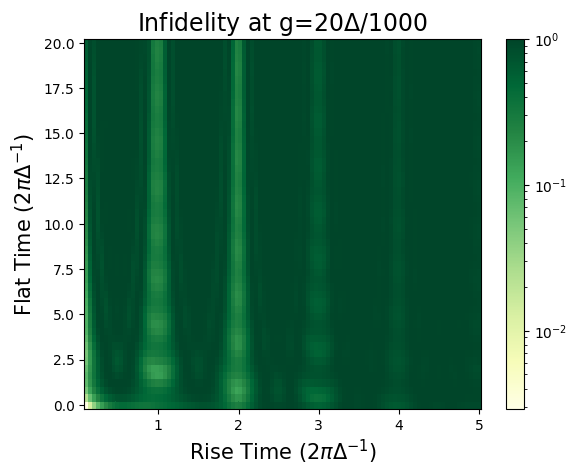

In [14]:

# Plotting infedility as a function of rise time and flat time
JCfideArray = JCSystem.qRes.resultsDict['JCfidelity']

flatList = np.array(tfSweep.sweepList)
trList = trSweep.sweepList
x, y = np.meshgrid(flatList, trList)
cmap = plt.get_cmap("YlGn")
infidelity = 1 - np.array(JCfideArray)  

plt.pcolor(y, x, infidelity, rasterized=True, cmap=cmap, norm=LogNorm(vmin=np.min(infidelity), vmax=1))
plt.xlabel(r'Rise Time ($2\pi\Delta^{-1}$)', fontsize=15)
plt.ylabel(r'Flat Time ($2\pi\Delta^{-1}$)', fontsize=15)
plt.title(r'Infidelity at g=' + str(int(np.round(g*1000/delta))) + r'$\Delta/1000$', fontsize=17)
plt.colorbar()
plt.show()

# qg.saveQResCSV(total_sys.qRes, 'JC Sinusoidal Pulse Sweep', "Test",dateTime=True)
 

# Further Optimisation

Since we are only simulating the ramp up portion of the pulse, we can improve the efficiency of our code by removing the flat time (tf) combinatorial sweep. Instead we can use a loop in our postCompute function which iterates over the tf values and computes the unitary fidelities.

As of yet, Quanguru does not have the functionality to define combinatorial sweeps in this way. But this may be added in future updates.

In [15]:
#Save tf sweep list and remove tfSweep

tfSweepList = tfSweep.sweepList
JCSystem.Sweep.removeSweep(tfSweep)

In [16]:
def optimisedPostCompute(qSim):
    cavdim = qSim.getByNameOrAlias('cavity').dimension
    fidelityList = []
    for tf in tfSweepList:
        time = 2*qSim.auxDict['tr'] + tf
        uSmooth = qSim.protocols[0].currentState

        # Forms the final unitary by left matrix multiplying the unitary obtained at the end of the rise time with the
        # unitary for the flat duration followed by the fall time ( = transpose of rise time unitary)
        uSmooth = np.transpose(uSmooth)@qg.UJC(wq+qSim.auxDict['amp'],wc,g,tf,cavdim,sparse=True)@uSmooth

        tsim = integrator(qSim.auxDict['amp'],qSim.auxDict['tr'],tf, time)[0]   


        # Compute the unitary of an ideal sqaure pulse
        uJC = qg.UJC(wc,wc,g,tsim,cavdim,sparse=True)

        # Apply phase correction
        integral = dOmegaSineInt(time,qSim.auxDict['amp'],qSim.auxDict['tr'],tf)
        
        uz = linA.expm(-0.5j*integral*sp.kron(qg.identity(cavdim), qg.sigmaz(), 'csc').toarray() + 1j*wc*time*sp.kron(qg.number(cavdim), qg.identity(2), 'csc').toarray())
        uz2 = linA.expm(0.5j*wc*tsim*sp.kron(qg.identity(cavdim), qg.sigmaz(), 'csc').toarray() - 1j*wc*tsim*sp.kron(qg.number(cavdim), qg.identity(2), 'csc').toarray())
        uSmooth = uz2@uz@uSmooth
        fidelityList.append(jfidelity(uJC,uSmooth))

    qSim.qRes.resultsDict['JCfidelity'] = fidelityList

JCSystem.postCompute = optimisedPostCompute

In [17]:
### Running the Simulation again
JCSystem.delStates = True
JCSystem.run(p=(platform.system() != 'Windows'), showProgress=True)

Starting sequential sweep with 100 parameter combinations...
Simulation Start:	2025-11-30 16:26:35
[████████████████████████████████████████] 100.0% | Est. Finish: 2025-11-30 16:27:42
Simulation completed in 00h 01m 06s

[]

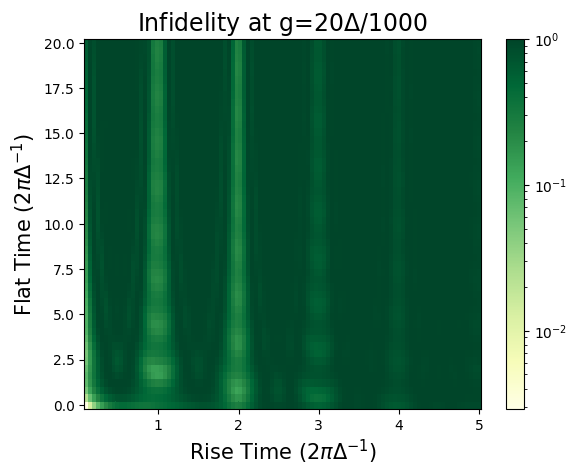

In [18]:
JCfideArray = JCSystem.qRes.resultsDict['JCfidelity']

flatList = np.array(tfSweep.sweepList)
trList = trSweep.sweepList
x, y = np.meshgrid(flatList, trList)
cmap = plt.get_cmap("YlGn")
infidelity = 1 - np.array(JCfideArray)  

plt.pcolor(y, x, infidelity, rasterized=True, cmap=cmap, norm=LogNorm(vmin=np.min(infidelity), vmax=1))
plt.xlabel(r'Rise Time ($2\pi\Delta^{-1}$)', fontsize=15)
plt.ylabel(r'Flat Time ($2\pi\Delta^{-1}$)', fontsize=15)
plt.title(r'Infidelity at g=' + str(int(np.round(g*1000/delta))) + r'$\Delta/1000$', fontsize=17)
plt.colorbar()
plt.show()
